# <font color='#2C3E50'> **Segundo Intento: Data Science Fundamentals**
---

**Analista:** Karen Herrera
**Fecha:** 05/13/2026

---

### **Descripción del Proyecto**

> El objetivo de este análisis es impiar y explorar un dataset que contiene información sobre las ventas de videojuegos en el año 2024. Este análisis es crucial para entender las tendencias de mercado y los factores que influyen en las ventas de videojuegos. El dataset puede ser encontrado en: https://www.kaggle.com/datasets/asaniczka/video-game-sales-2024

--- </font>

# <font color='#2C3E50'>**SECCION 1. CARGA Y PRIMERA EXPLORACION**
**Cargar el dataset | head | tail | info | describe | shape** </font>

>## <font color='#27AE60'>**Paso 1.1 Configuracion e importaciones** </font>

In [42]:
import pandas as pd
import plotly.express as px
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

# visualización de Pandas para ver todas las columnas y formatear todos los decimales a dos puntos decimales
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


> ## <font color='#27AE60'>**Paso 1.2 Cargar el dataset**</font>

In [ ]:
file_path = '/content/sample_data/vgchartz-2024.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset cargado exitosamente!!")
    print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
    print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
    print(f'\nColumnas: {list(df.columns)}')

except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no se encontró. Por favor, verifica la ruta.")
    exit()



Dataset cargado exitosamente!!
Dimensiones: 64016 filas x 14 columnas
Memoria aproximada: 33512 KB

Columnas: ['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update']


> ## <font color='#27AE60'>**Paso 1.3. Primeras y ultimas filas**</font>

In [ ]:
print('=== Primeras 5 filas ===')
display(df.head())
print('\n=== Ultimas 5 filas ===')
display(df.tail())


=== Primeras 5 filas ===


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.40,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.70,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.60,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.10,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14



=== Ultimas 5 filas ===


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11,2019-01-28
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28,2019-02-24
64015,/games/boxart/default.jpg,Yurukill: The Calumniation Games,PS4,Visual Novel,Unknown,G.rev Ltd.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-09-29


> ## <font color='#27AE60'>**Paso 1.4 Estructura general**</font>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


El dataset tiene 64016.

columnas developer, critic_score, total_sales, na_sales, na_sales, jp_sales, pal_sales, other_sales, release_date y last_update con datos nulos (9 columnas, 64% del dataset ❗)

Las columnas release_date y last_update deben ser datetime y estan como objeto.

> ## <font color='#27AE60'>**Paso 1.5 Estadisticas descriptivas**</font>

In [ ]:
df.describe()
print('=== Columnas numericas ===')
display(df.describe())
print('\n=== Columnas categoricas ===')
display(df.describe(include='object'))

=== Columnas numericas ===


,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.00,18922.00,12637.00,6726.00,12824.00,15128.00
mean,7.22,0.35,0.26,0.10,0.15,0.04
std,1.46,0.81,0.49,0.17,0.39,0.13
min,1.00,0.00,0.00,0.00,0.00,0.00
25%,6.40,0.03,0.05,0.02,0.01,0.00
50%,7.50,0.12,0.12,0.04,0.04,0.01
75%,8.30,0.34,0.28,0.12,0.14,0.03
max,10.00,20.32,9.76,2.13,9.85,3.12



=== Columnas categoricas ===


,img,title,console,genre,publisher,developer,release_date,last_update
count,64016,64016,64016,64016,64016,63999,56965,17879
unique,56177,39798,81,20,3383,8862,7922,1545
top,/games/boxart/default.jpg,Plants vs. Zombies,PC,Misc,Unknown,Unknown,1994-01-01,2018-01-06
freq,7810,17,12617,9304,8842,4435,515,165


**Columnas Numericas**

EL promedio de total_sales es de 0.35 millones y el maximo 20.32 millones, es muy posible que hayan outliers muy altos en esta columna.

critic_score tiene una media 7.22, menor que la mediana 7.5, es posible que hayan ooutliers muy bajos que esten disminuyendo el valor de la media.

na_sales indica que Norteamerica lidera el promeido de ventas con 0.26


**Columnas Categoricas**   

La imagen /games/boxart/default.jpg aparece 7810 veces, la mayor parte del dataset no tiene una imagen asignada.

El mayor valor de title es 64016 con 39798 valores unicos, siendo Plants vs Zombies el que aparece mas veces. Los juegos se repiten porque salieron en varias consolas.

El valor de la columna consola más frecuente es PC con 12617 registros (casi el 20% del dataset).

En la columna genre hay 20 valores únicos, el más común es Misc con 9304 registros. Muchos juegos no tienen una categoría clara o bien definida.

En las columnas publisher y developer el valor mas frecuente es unknown (4884 y 4435 respectivamente).

La columna release_date tiene como valor mas comun el 01-01-1994 con 515 veces, quizas en algunos juegos se sabia el anio de su liberacion mas no el mes y dia exactos y se puso el 1ro de enero por defecto, esto podria ser un sesgo que afecte el analisis


#<font color='#2C3E50'> **SECCION 2. LIMPIEZA DE DATOS**

**tipos | duplicados | inconsistencias | nulos | outliers**</font>

> ## <font color='#27AE60'>**Paso 2.1 Verificar y corregir tipos de datos**</font>

In [ ]:
print('Tipos ANTES de limpiar:')
print(df.dtypes)
print()

Tipos ANTES de limpiar:
img              object
title            object
console          object
genre            object
publisher        object
developer        object
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date     object
last_update      object
dtype: object



In [ ]:
# --- release_date y last_update: deberian ser datetime por ser fechas
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['last_update'] = pd.to_datetime(df['last_update'], errors='coerce')

# --- critic_score, total_sales, na_sales, jp_sales, pal_sales y other_sales: verifico que sean flotantes y elimino espacios o caracterer raros
columnas_float = ['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales','other_sales']
for columna in columnas_float:
  df[columna]=pd.to_numeric(df[columna], errors='coerce')

print('Tipos DESPUES de limpiar:')
print(df.dtypes)


Tipos DESPUES de limpiar:
img                     object
title                   object
console                 object
genre                   object
publisher               object
developer               object
critic_score           float64
total_sales            float64
na_sales               float64
jp_sales               float64
pal_sales              float64
other_sales            float64
release_date    datetime64[ns]
last_update     datetime64[ns]
dtype: object


> ## <font color='#27AE60'>**Paso 2.2 Identificar y eliminar duplicados**</font>

In [ ]:
n_total = len(df)
# duplicados exactos
exactly_dupes = df.duplicated().sum()

# duplicados logicos
# se considera que si dos registros tienen el mismo titulo, consola y fecha de liberacion considerarlo un valor duplicado
clave = ['title', 'console', 'release_date']
logical_dupes = df.duplicated(subset=clave).sum()
print(f'Se encontraron {logical_dupes} duplicados logicos (mismo titulo, consola y fecha de liberacion)')

# Eliminar duplicados, se mantiene el primero que aparezca y el resto lo borro, y reseteo el indice
df = df.drop_duplicates(subset=clave, keep='first').reset_index(drop=True)

print(f'Filas totales iniciales:         {n_total}')
print(f'Duplicados exactos encontrados:  {exactly_dupes} ({exactly_dupes/n_total*100:.1f}%)')
print(f'Duplicados lógicos encontrados:  {logical_dupes} ({logical_dupes/n_total*100:.1f}%)')
print(f'---')
print(f'Registros finales en el dataset: {len(df)}')

Se encontraron 139 duplicados logicos (mismo titulo, consola y fecha de liberacion)
Filas totales iniciales:         64016
Duplicados exactos encontrados:  0 (0.0%)
Duplicados lógicos encontrados:  139 (0.2%)
---
Registros finales en el dataset: 63877


> ## <font color='#27AE60'> **Paso 2.3 Inconsistencias en valores categoricos** </font>

In [19]:
# lista de columnas categoricas para revisarlas todas con un for
columnas_categoricas = ['console', 'genre', 'publisher', 'developer']
for columna in columnas_categoricas:
  valores_unicos_iniciales = df[columna].nunique()
  df[columna] = df[columna].astype(str).str.strip().str.capitalize()
  valores_unicos_finales = df[columna].nunique()
  print(f"Columna {columna}: Los valores unicos pasaron de {valores_unicos_iniciales} a {valores_unicos_finales}")

# Convertir 'Nan' en un nulo real y luego a 'Unknown'
df['developer'] = df['developer'].replace('Nan', np.nan).fillna('Unknown')
df['publisher'] = df['publisher'].replace('Nan', np.nan).fillna('Unknown')
df['genre'] = df['genre'].replace('Nan', np.nan).fillna('Unknown')

# Probando el resultado con la columna genre
print("----- Generos-----\n")
print(df['genre'].unique())


Columna console: Los valores unicos pasaron de 81 a 81
Columna genre: Los valores unicos pasaron de 20 a 20
Columna publisher: Los valores unicos pasaron de 3383 a 3383
Columna developer: Los valores unicos pasaron de 8850 a 8850
----- Generos-----

['Action' 'Shooter' 'Action-adventure' 'Sports' 'Role-playing'
 'Simulation' 'Racing' 'Music' 'Misc' 'Fighting' 'Platform' 'Adventure'
 'Strategy' 'Puzzle' 'Mmo' 'Sandbox' 'Party' 'Education' 'Board game'
 'Visual novel']


> ## <font color='#27AE60'>**Paso 2.4 Analisis de valores nulos**</font>

In [12]:
null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)
df = df.replace('Nan', np.nan)

print('=== Columnas con valores nulos ===')
display(null_report)

=== Columnas con valores nulos ===


,Nulos,Porcentaje,Umbral
critic_score,57226,89.59,Eliminar columna (> 50%)
jp_sales,57181,89.52,Eliminar columna (> 50%)
na_sales,51258,80.24,Eliminar columna (> 50%)
pal_sales,51071,79.95,Eliminar columna (> 50%)
other_sales,48765,76.34,Eliminar columna (> 50%)
last_update,46023,72.05,Eliminar columna (> 50%)
total_sales,45006,70.46,Eliminar columna (> 50%)
release_date,7050,11.04,Imputar (< 30%)


Tengo 8 columnas con valores nulos, de las cuales 7 tienen entre 70-80% de valores nulos. De acuerdo a lo establecido en mi codigo deberia eliminarlas, pero de hacerlo me quedo sin informacion para realizar el analisis de las ventas (que es el objetivo del estudio), por lo cual tendre que imputar algunas columnas, aun con un alto porcentaje de nulos

| Columna | Nulos % | Estrategia | Justificación |
| :--- | :--- | :--- | :--- |
| **Criting_score** | ~90% | Mediana por genre | Las métricas de calidad suelen ser similares dentro de un mismo género; la mediana reduce el impacto de valores extremos.|
| **jp_sales** | ~90% | 0.00 | ASumire que la falta de datos es porque no se registraron ventas, valor = 0. |
| **na_sales** | ~80% | 0.00 | ASumire que la falta de datos es porque no se registraron ventas, valor = 0. |
| **pal_sales** | ~80% | 0.00 | ASumire que la falta de datos es porque no se registraron ventas, valor = 0. |
| **other_sales** | ~76% | 0.00 | ASumire que la falta de datos es porque no se registraron ventas, valor = 0. |
| **last_updates** | ~72% | Drop columna| No es relevante para el análisis de ventas de los videojuegos. |
| **total_sales** | ~70% | sum | Rellenare con la suma de las ventas en cada region |
| **release_date** | ~11% | drop filas | Al ser un volumen bajo de nulos, se eliminan para asegurar que todo el análisis por año sea veraz. |


> ## <font color='#27AE60'>**Paso 2.5 Manejo de Nulos - Imputaciones** </font>


Eliminacion de columnas innecesarias para el analisis de ventas de videojuegos (img y last_update)

In [13]:
df.drop(columns=['img', 'last_update'], inplace=True)
print(df.columns.tolist())

['title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date']


Imputacion de columna critic_score por la mediana por genre

In [20]:
# Utilizo transform para que cada celda nula se llene con la mediana de su propio grupo
df['critic_score'] = df['critic_score'].fillna(df.groupby('genre')['critic_score'].transform('median'))

# si quedan nulos (genre sin calificacion), uso la mediana global
mediana_global = df['critic_score'].median()
df['critic_score'] = df['critic_score'].fillna(mediana_global)
print(f"Nulos restantes en critic_score: {df['critic_score'].isnull().sum()}")

Nulos restantes en critic_score: 0


**Nota**: Se consulto notebooks del profesor Cristian

Imputacion de columnas de ventas regionales: na_sales, jp_sales, pal_sales y other_sales

In [21]:
columnas_ventas_regionales = ['na_sales', 'pal_sales', 'jp_sales', 'other_sales']
df[columnas_ventas_regionales] = df[columnas_ventas_regionales].fillna(0)

print("Nulos en ventas regionales:", df[columnas_ventas_regionales].isnull().sum().sum())

Nulos en ventas regionales: 0


Imputacion con suma en la columna de total_sales

In [22]:
df['total_sales'] = df['total_sales'].fillna(df[columnas_ventas_regionales].sum(axis=1))
print("Nulos en total_sales:", df['total_sales'].isnull().sum())

Nulos en total_sales: 0


Imputacin de release_date (drop filas)

In [23]:
df = df.dropna(subset=['release_date'])

print(f"Nulos restantes en release_date: {df['release_date'].isnull().sum()}")


Nulos restantes en release_date: 0


**Reporte final de registros nulos**

In [26]:
null_report_final = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Nulos', ascending=False)

print('=== REPORTE FINAL DE INTEGRIDAD DE DATOS ===')
display(null_report_final)

print(f"\nCantidad final de registros despues de eliminar nulos: {len(df)}")

=== REPORTE FINAL DE INTEGRIDAD DE DATOS ===


,Nulos,Porcentaje
title,0,0.00
console,0,0.00
genre,0,0.00
publisher,0,0.00
developer,0,0.00
critic_score,0,0.00
total_sales,0,0.00
na_sales,0,0.00
jp_sales,0,0.00
pal_sales,0,0.00



Cantidad final de registros despues de eliminar nulos: 56827


> ## <font color='#27AE60'>**Paso 2.6 Identificar y eliminar outliers**</font>

In [27]:
print('=== ANALISIS DE OUTLIERS ===')
print()

# --- total_sales, na_sales, pal_sales, other_sales y  jp_sales no pueden tener valores negativos ---
columnas_ventas = ['na_sales', 'pal_sales', 'jp_sales', 'other_sales', 'total_sales']
mask_ventas_negativas = (df[columnas_ventas] < 0).any(axis=1)
ventas_negativas = df[mask_ventas_negativas]
print(f'Ventas fuera del rango (negativos): {len(ventas_negativas)} filas')

# --- Critic Score debe estar entre 0 y 10 (o 100) ---
mask_score_invalido = (df['critic_score'] < 0) | (df['critic_score'] > 10)
score_invalido = df[mask_score_invalido]
print(f'Critic Scores inválidos (fuera de rango 0-10): {len(score_invalido)} filas')

#  --- total_sales: usamos IQR para detectar valores extremos o outliers --
q1, q3 = df['total_sales'].quantile([0.25, 0.75])
iqr = q3 - q1
lim_total = q3 + 1.5 * iqr
outliers_total = df[df['total_sales'] > lim_total]

print(f'\nReviews:')
print(f'  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}  Limite IQR={lim_total:.2f}')
print(f'  Videojuegos con total sales > limite IQR: {len(outliers_total)} ({len(outliers_total)/len(df)*100:.1f}%)')
print(f'  Son super ventas, videojuegos con éxito de ventas -- no eliminar')
print(f'  Decisión: se mantienen (son valores reales, éxitos de venta)')

# 3. Limpieza efectiva
filas_antes = len(df)

# Aplicamos los filtros inversos para eliminar los errores lógicos detectados en el paso 1
df = df[~mask_ventas_negativas]
df = df[~mask_score_invalido]

print(f'\nFilas eliminadas por valores imposibles: {filas_antes - len(df)}')
print(f'Dataset limpio final: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Nulos totales: {df.isnull().sum().sum()}')

=== ANALISIS DE OUTLIERS ===

Ventas fuera del rango (negativos): 0 filas
Critic Scores inválidos (fuera de rango 0-10): 0 filas

Reviews:
  Q1=0.00  Q3=0.03  IQR=0.03  Limite IQR=0.07
  Videojuegos con total sales > limite IQR: 11338 (20.0%)
  Son super ventas, videojuegos con éxito de ventas -- no eliminar
  Decisión: se mantienen (son valores reales, éxitos de venta)

Filas eliminadas por valores imposibles: 0
Dataset limpio final: 56827 filas x 12 columnas
Nulos totales: 0


**Nota** Para el uso de mask se consulto a la ia y notebooks del profesor Cristian

> ## <font color='#27AE60'>**Resumen del Dataset Limpio** </font>

In [28]:
print('=== RESUMEN DE LIMPIEZA DEL DATASET ===')
print('-' * 40)

filas_finales = df.shape[0]
columnas_finales = df.shape[1]
nulos_totales = df.isnull().sum().sum()

print(f'1. ESTRUCTURA FINAL:')
print(f'   - Registros: {filas_finales}')
print(f'   - Columnas:  {columnas_finales}')

print(f'\n2. ESTADO DE NULOS:')
if nulos_totales == 0:
    print('   - ¡Dataset 100% limpio! No se detectaron valores nulos.')
else:
    print(f'   - Nulos residuales: {nulos_totales}')
    print(df.isnull().sum()[df.isnull().sum() > 0])

print(f'\n3. TIPOS DE DATOS POR COLUMNA:')
print(df.dtypes.value_counts())

print(f'\n4. MUESTRA DE DATOS LIMPIOS (Primeras 3 filas):')
display(df.head(3))


=== RESUMEN DE LIMPIEZA DEL DATASET ===
----------------------------------------
1. ESTRUCTURA FINAL:
   - Registros: 56827
   - Columnas:  12

2. ESTADO DE NULOS:
   - ¡Dataset 100% limpio! No se detectaron valores nulos.

3. TIPOS DE DATOS POR COLUMNA:
float64           6
object            5
datetime64[ns]    1
Name: count, dtype: int64

4. MUESTRA DE DATOS LIMPIOS (Primeras 3 filas):


,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date
0,Grand Theft Auto V,Ps3,Action,Rockstar games,Rockstar north,9.40,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,Ps4,Action,Rockstar games,Rockstar north,9.70,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,Ps2,Action,Rockstar games,Rockstar north,9.60,16.15,8.41,0.47,5.49,1.78,2002-10-28


# <font color='#2C3E50'> **SECCION 3 EXPLORACION DE DATOS (EDA)**
**Univariante x2 | Multivariante x2 | Interpretacion** </font>

> ## <font color='#27AE60'>**Visualizacion Univariante 1 -- Histograma de Critic_score **</font>

**Objetivo:** Entender la distribucion de la calificacion de los videojuegos

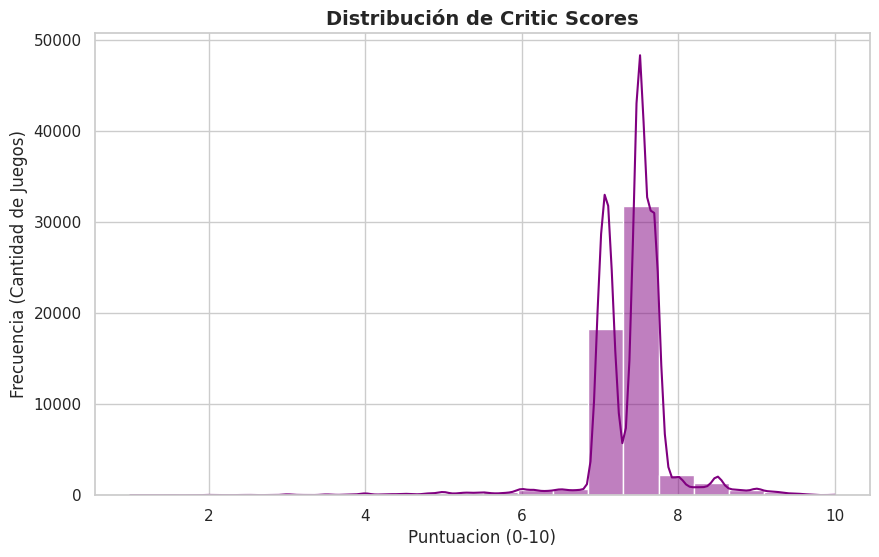

In [32]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['critic_score'], bins=20, kde=True, color='purple')
plt.title('Distribución de Critic Scores', fontsize=14, fontweight='bold')
plt.xlabel('Puntuacion (0-10)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Juegos)', fontsize=12)
plt.show()

>**Analisis**

La grafica tiene un sesgo a la derecha, eL valor mas alto de la grafica esta alrededor de la mediana, debido a la imputacion realizada. La mayoria de las calificaciones se encuentran entre 6 y 8 puntos, es decir, los videojuegos tienen una calificacion estable y de valores altos.

> ## <font color='#27AE60'>**Visualizacion Univariante 2 -- BarPlot Genre - Categorias de juegos ** </font>

**Objetivo:** Identificar cuantos juegos hay por categoria para descubrir tendencias

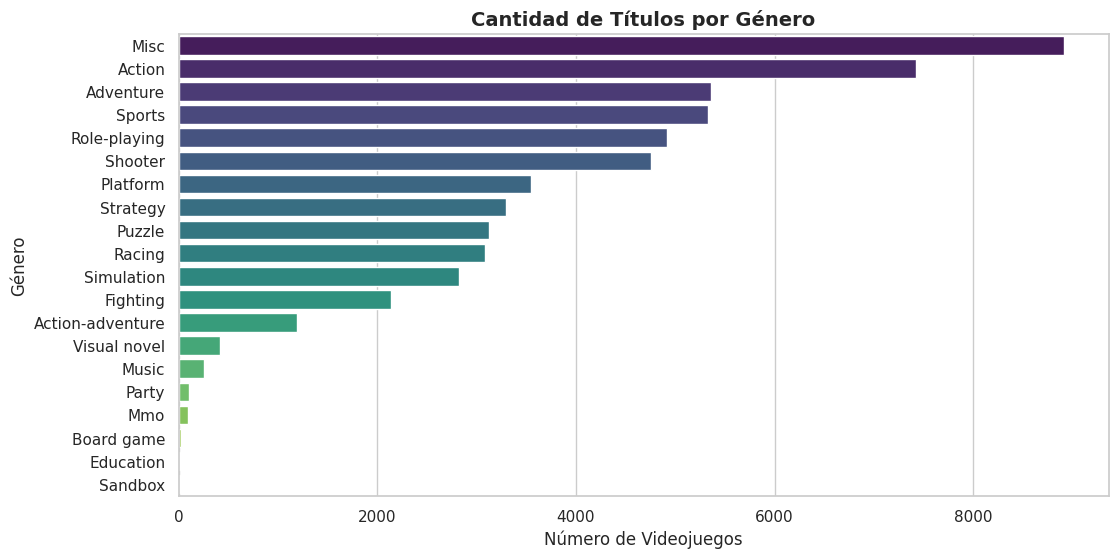

In [34]:
plt.figure(figsize=(12, 6))
order = df['genre'].value_counts().index
sns.countplot(data=df, y='genre', order=order, palette='viridis')
plt.title('Cantidad de Títulos por Género', fontsize=14, fontweight='bold')
plt.xlabel('Número de Videojuegos', fontsize=12)
plt.ylabel('Género', fontsize=12)
plt.show()


>**Analisis**

La categoria de juegos mas vendida es Action, seguida de Shooter y Sports.

Como ya se habia visto en el analisis previo, la mayoria de los juegos son clasificados como miscelaneos, lo que sesga el resultado


> ## <font color='#27AE60'>**Visualizacion Multivariante 1 -- Ventas totales vs Critical_score **</font>

**Objetivo:** Comparar la distribucion de las ventas totales por categoria contra la calificacion para identificar si existe correlacion entre las mismas

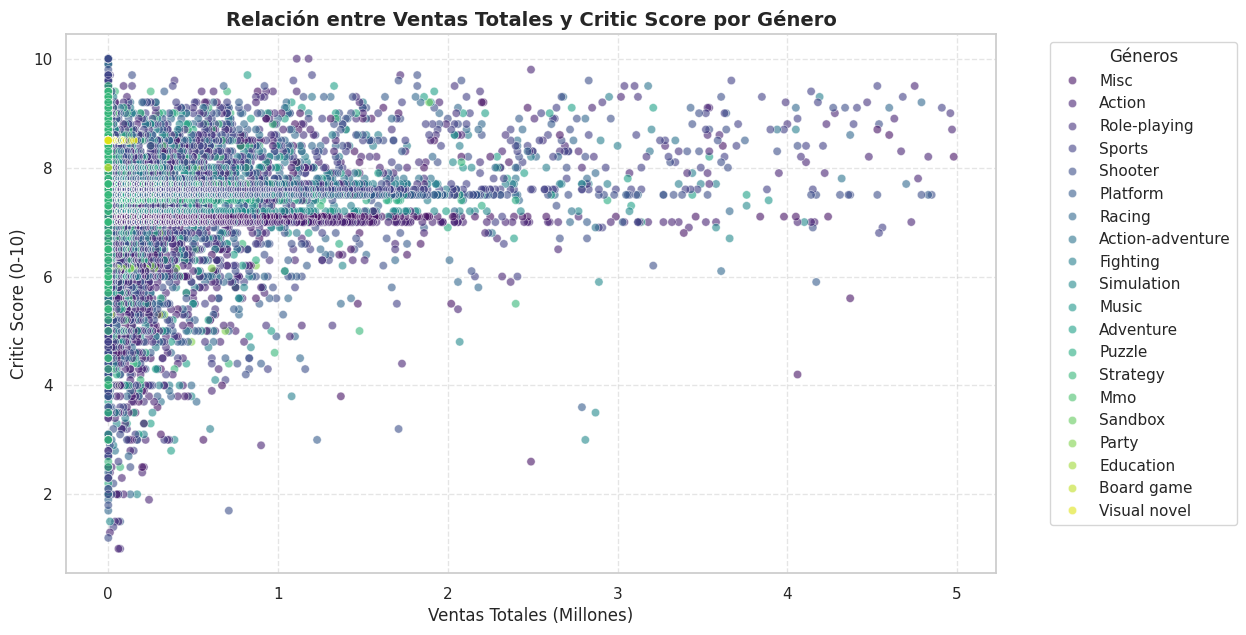

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df[df['total_sales'] < 5],
                x='total_sales',
                y='critic_score',
                hue='genre',
                alpha=0.6,
                palette='viridis')
plt.title('Relación entre Ventas Totales y Critic Score por Género', fontsize=14, fontweight='bold')
plt.xlabel('Ventas Totales (Millones)', fontsize=12)
plt.ylabel('Critic Score (0-10)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Géneros')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Analisis**

Los valores que se agrupan como en una linea horizoantal son debidos a la imputacion hecha por la mediana en el critic_score (valor 7.5)

La mayoria de los puntos esta pegado al eje y, y con ventas entre 0 y 2 millones, a pesar de que las calificaciones son casi todas altas, esa puntuacion no garantiza ventas altas.

Los puntos que tienen ventas entre 3 y 5 millones, casi todos tienen critical_score mayor a 7. Osea, una alta calificacion no implica altas ventas pero una alta venta si esta ligada a una alta calificacion.

Los puntos de Action, Role playing, sports y Shooters son los que estan mas a la derecha del grafico, es decir, se venden mas. Los Board Games, Visual Novels, Education, PArty estan agrupados hacia el lado izquierdo, es decir, tienen menores ventas


> ## <font color='#27AE60'>**Visualizacion Multivariante 2 -- Ventas por region por genre**</font>

**Objetivo:** Identificar si los gustos por las diferentes categorias de videojuegos varian entre las regiones

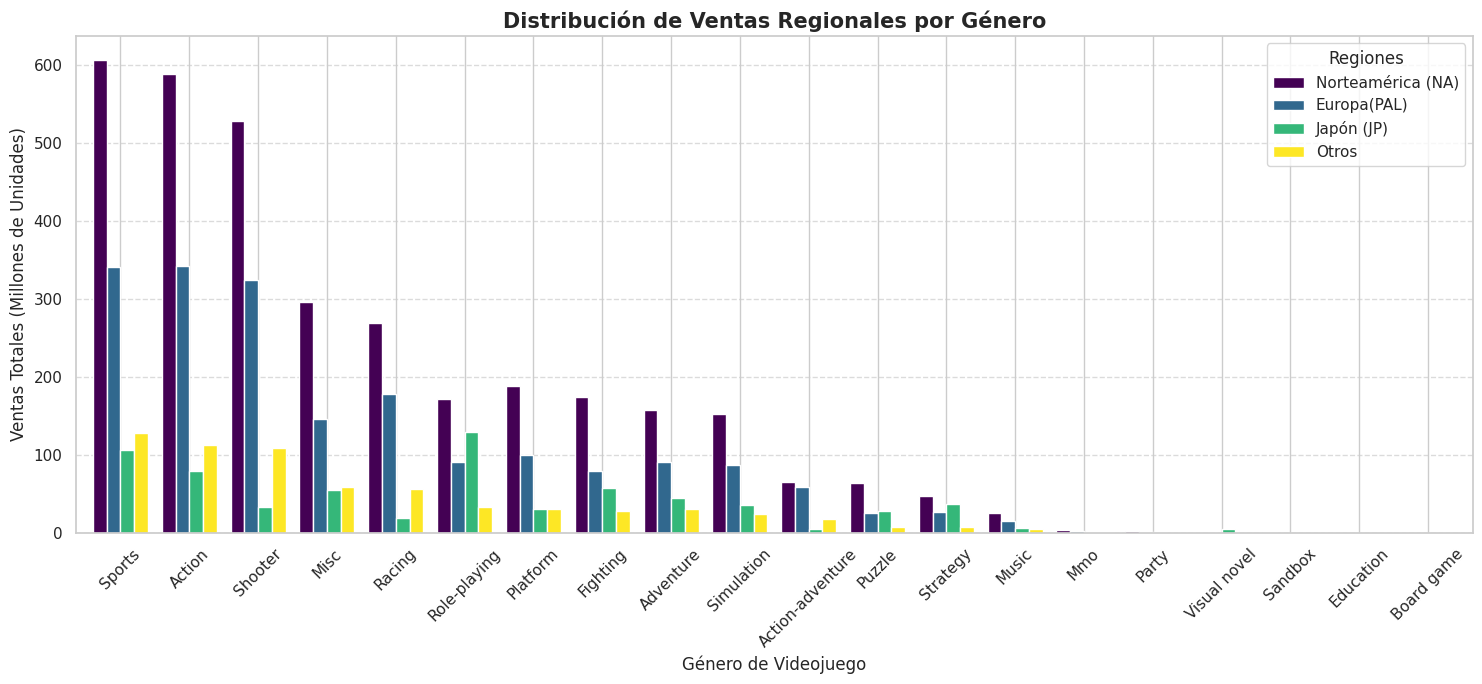

In [36]:
# agrupo los datos por género y sumo las ventas regionales
ventas_por_genero = df.groupby('genre')[['na_sales', 'pal_sales', 'jp_sales', 'other_sales']].sum()

# ordeno por ventas totales
ventas_por_genero['total_temp'] = ventas_por_genero.sum(axis=1)
ventas_por_genero = ventas_por_genero.sort_values('total_temp', ascending=False).drop(columns='total_temp')

ax = ventas_por_genero.plot(kind='bar', figsize=(15, 7), width=0.8, colormap='viridis')
plt.title('Distribución de Ventas Regionales por Género', fontsize=15, fontweight='bold')
plt.xlabel('Género de Videojuego', fontsize=12)
plt.ylabel('Ventas Totales (Millones de Unidades)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Regiones', labels=['Norteamérica (NA)', 'Europa(PAL)', 'Japón (JP)', 'Otros'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Analisis**

En casi todos los generos, la barra de Norteamerica es la mas alta, seguida de la de Europa, es decir, el mayor volumen de ventas se concentra en estas regiones, siendo sports, action y shooter las categorias mas vendidas, y music, strategy y puzzle las menos vendidas.

En el mercado japones, los juegos de role playing son los mas vendidos, y los de racing, shooter, platform y music los de menores ventas.

> ## <font color='#27AE60'>**Analisis Adicional**</font>


# **Estadisticas Descriptivas**
Se realiza solo para las columnas numericas

In [37]:
columnas_numericas = ['na_sales', 'pal_sales', 'jp_sales', 'other_sales', 'total_sales', 'critic_score']

estadisticas = df[columnas_numericas].describe().T
estadisticas['median'] = df[columnas_numericas].median()
estadisticas['var'] = df[columnas_numericas].var()

# Reordenamos y redondeamos para que sea legible
estadisticas = estadisticas[['count', 'mean', 'median', 'std', 'var', 'min', 'max']].round(2)

print('=== ESTADISTICAS DE LAS COLUMNAS NUMÉRICAS ===')
display(estadisticas)

=== ESTADISTICAS DE LAS COLUMNAS NUMÉRICAS ===


,count,mean,median,std,var,min,max
na_sales,56827.00,0.06,0.00,0.26,0.07,0.00,9.76
pal_sales,56827.00,0.03,0.00,0.20,0.04,0.00,9.85
jp_sales,56827.00,0.01,0.00,0.07,0.00,0.00,2.13
other_sales,56827.00,0.01,0.00,0.07,0.00,0.00,3.12
total_sales,56827.00,0.12,0.00,0.49,0.24,0.00,20.32
critic_score,56827.00,7.38,7.50,0.57,0.32,1.00,10.00


#**Identificacion de Tendencias**

Los videojuegos de Action, Sports y Shooter son los lideres en ventas, y sus ventas son mayores a la sumatoria de las ventas del resto de los generos.

El volumen de ventas esta concentrado en el mercado Norteamericano, seguido por el Europeo.

El mercado japones tiene un comportamiento diferente al resto.

El critical_score no tiene influencia en las ventas.

**PD:** **Estas tendencias deben interpretarse con cautela, debido a las imputaciones realizadas por la gran cantidad de datos nulos en las columnas numericas, y la gran cantidad de filas "miscelaneas" en la columna de genere. Lo cual genera un sesgo en los resultados**

#**Analisis de Correlacion**
Se realizara un heatmap para ver las relaciones entre las columnas numericas

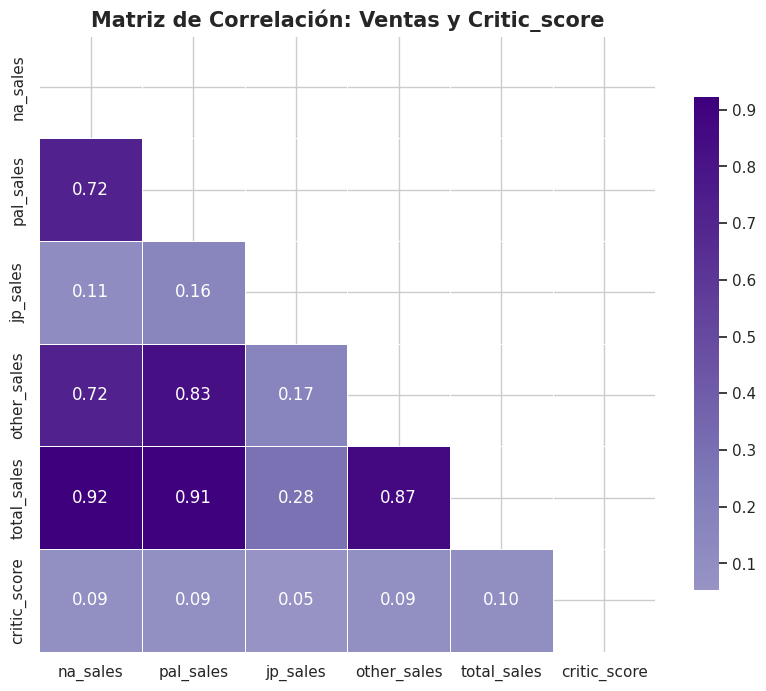

In [41]:
columnas_numericas = ['na_sales', 'pal_sales', 'jp_sales', 'other_sales', 'total_sales', 'critic_score']
matriz_correlacion = df[columnas_numericas].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

sns.heatmap(matriz_correlacion,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='Purples',
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación: Ventas y Critic_score', fontsize=15, fontweight='bold')
plt.show()

**Analisis**:
La correlacion mas fuerte es entre total sales y na_sales y pal_sales, (0.91) como ya lo habiamos visto antes, las mayores ventas estan en estos dos mercados (norteamerica y europa).

La correlacion entre critic_score y total_sales es casi nula.(imputamos la mayoria de los datos por la mediana y esto afecta los resultados).

La correlacion entre na_sales y pa_sales es de 0.72, estos mercados se comportan de manera similar.

La correlacion entre jp_sales y total_sales es 0.28, lo que refuerza que es un mercado con gustos diferente que no sigue las tendencias del mercado global. En cambio, para other_sales, la correlacion de 0.87 indica que estos mercados si siguen las tendencias marcadas por norteamerica y europa.





#**Modelo de Regresion Simple**
Como la correlacion entre na_sales y total_sales es de 0.91, utilizare na_sales para predecir el valor de total_sales

In [44]:
# Datos (X = dataFrame, y= vector)
X = df[['na_sales']]
y = df['total_sales']

# (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#creación y entrenamiento del modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)

# Métricas de evaluación
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'=== RESULTADOS DEL MODELO DE PREDICCIÓN ===')
print(f'Coeficiente (Pendiente): {modelo.coef_[0]:.4f}')
print(f'Intercepto: {modelo.intercept_:.4f}')
print(f'Coeficiente de Determinación (R²): {r2:.4f}')
print(f'Error Cuadrático Medio (RMSE): {rmse:.4f}')

=== RESULTADOS DEL MODELO DE PREDICCIÓN ===
Coeficiente (Pendiente): 1.7797
Intercepto: 0.0112
Coeficiente de Determinación (R²): 0.8233
Error Cuadrático Medio (RMSE): 0.1941


El modelo me indica que el 82.33% de la variacion en las ventas totales se explica conociendo solo las ventas de norteamerica, es decir, el modelo es confiable.

El error cuadratico me dice que las predicciones se desvian 0.1941 millones del valor real (194000), es un error bajo, el modelo es preciso

**Grafica recta de Regresion**

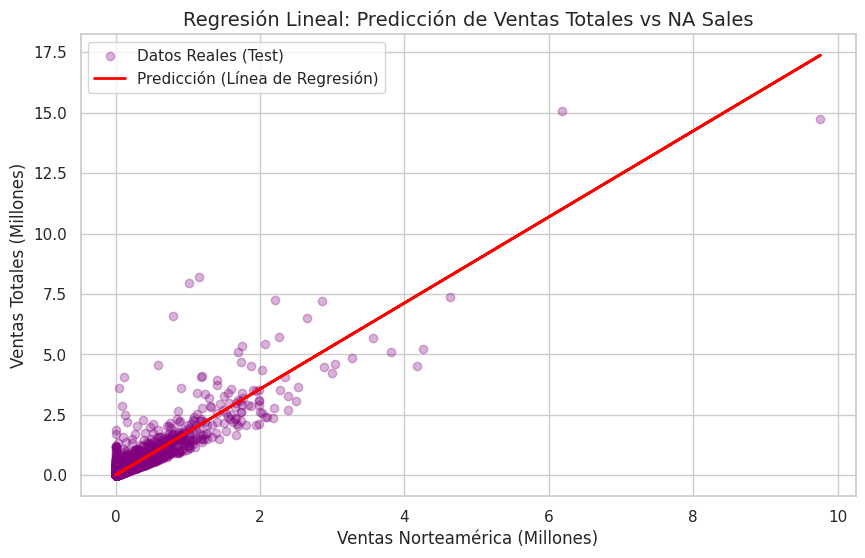

In [45]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='purple', alpha=0.3, label='Datos Reales (Test)')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicción (Línea de Regresión)')
plt.title('Regresión Lineal: Predicción de Ventas Totales vs NA Sales', fontsize=14)
plt.xlabel('Ventas Norteamérica (Millones)')
plt.ylabel('Ventas Totales (Millones)')
plt.legend()
plt.show()

**Analisis**

Los puntos morados (datos reales) se agrupan muy cerca de la línea roja (predicción). A medida que aumentan las ventas en norteamerica, aumentan las ventas totales.

Hay algunos outliers

**Nota**
Para la realizacion del modelo de regresion y su grafico se consulto al documentacion oficial https://scikit-learn.org/stable/modules/linear_model.html y modelos de llm